In [1]:
import pandas as pd


In [2]:
gigi = pd.read_parquet("/home/renku/work/store/parquet_data/HackDays2026 - GIGI.parquet")

test = pd.read_parquet("/home/renku/work/store/parquet_data/2024/April 2024/LG_AIM2Hackerdays_kWh_20260812_070837.parquet")


In [3]:
gigi.head()

,GP-Nr,PLZ,Ort,Kanton,WärmePumpe,PV,PV-Leistung in kWp,Batterie/Speicher,Ladestation für Elektrofahrzeuge,Wärmepumpenboiler,Datum Unterschrift,geplanter Baustart,Übergabe,InBetrieb-Datum
0,698970,5452.0,Oberrohrdorf,AG,-,x,NaN,-,-,-,18.04.2008,NaN,NaN,NaN
1,NaN,5024.0,Küttigen,AG,-,-,NaN,-,-,-,01.01.2017,NaN,NaN,NaN
2,196344,5732.0,Zetzwil,AG,-,-,NaN,-,-,-,01.01.2017,NaN,NaN,21.06.2017
3,570021,5023.0,Biberstein,AG,x,-,NaN,-,-,-,01.07.2017,NaN,NaN,24.11.2017
4,716671,8962.0,Bergdietikon,AG,x,x,NaN,x,-,-,24.08.2017,NaN,23.11.2017,04.12.2017


In [ ]:
test.head()

,MP ID,OBIS-Code,Datum,PLZ,00:15,00:30,00:45,01:00,01:15,01:30,...,21:45,22:00,22:15,22:30,22:45,23:00,23:15,23:30,23:45,00:00
0,53628,1-1:2.29.0*255,01.04.2024,5105.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,53628,1-1:2.29.0*255,02.04.2024,5105.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,53628,1-1:2.29.0*255,03.04.2024,5105.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,53628,1-1:2.29.0*255,04.04.2024,5105.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,53628,1-1:2.29.0*255,05.04.2024,5105.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
import pandas as pd

# Load lookup tables
mpid_map = pd.read_parquet(
    "../../store/parquet_data/mpid_zähler_mapping.parquet"
)

zaehler_gp = pd.read_parquet(
    "../../store/parquet_data/Zähler-GP.parquet"
)

gigi = pd.read_parquet(
    "../../store/parquet_data/HackDays2026 - GIGI.parquet"
)

# Clean column names
mpid_map.columns = mpid_map.columns.str.strip()
zaehler_gp.columns = zaehler_gp.columns.str.strip()
gigi.columns = gigi.columns.str.strip()

# Normalize IDs
mpid_map["MP ID"] = pd.to_numeric(
    mpid_map["MP ID"], errors="coerce"
).astype("Int64")

zaehler_gp["GPartner"] = pd.to_numeric(
    zaehler_gp["GPartner"], errors="coerce"
).astype("Int64")

gigi["GP-Nr"] = pd.to_numeric(
    gigi["GP-Nr"], errors="coerce"
).astype("Int64")

binary_cols = {
    "WärmePumpe": "has_heatpump",
    "PV": "has_pv",
    "Batterie/Speicher": "has_battery",
    "Ladestation für Elektrofahrzeuge": "has_ev_charger",
    "Wärmepumpenboiler": "has_heatpump_boiler",
}

for source_col, new_col in binary_cols.items():
    cleaned = (
        gigi[source_col]
        .astype(str)
        .str.strip()
        .str.lower()
    )

    gigi[new_col] = cleaned.map({
        "x": True,
        "-": False
    })

lookup = (
    mpid_map
    .merge(
        zaehler_gp[["Zählpunktbezeichnung", "GPartner"]],
        on="Zählpunktbezeichnung",
        how="left"
    )
    .merge(
        gigi[
            [
                "GP-Nr",
                "PLZ",
                "Ort",
                "Kanton",
                "has_pv",
                "has_heatpump",
                "has_battery",
                "has_ev_charger",
                "has_heatpump_boiler",
            ]
        ],
        left_on="GPartner",
        right_on="GP-Nr",
        how="left"
    )
)
bool_cols = list(binary_cols.values())
lookup[bool_cols].isna().any(axis=1).sum()
lookup[bool_cols] = lookup[bool_cols].fillna(False)

In [11]:
gp_from_zaehler = set(
    zaehler_gp["GPartner"]
    .dropna()
    .astype("Int64")
)

gp_from_gigi = set(
    gigi["GP-Nr"]
    .dropna()
    .astype("Int64")
)

overlap = gp_from_zaehler & gp_from_gigi

print("Unique GPartner:", len(gp_from_zaehler))
print("Unique GP-Nr:", len(gp_from_gigi))
print("Overlap:", len(overlap))
print("Example overlaps:", list(overlap)[:20])

Unique GPartner: 76718
Unique GP-Nr: 877
Overlap: 337
Example overlaps: [np.int64(821251), np.int64(821253), np.int64(821258), np.int64(722955), np.int64(749578), np.int64(821264), np.int64(821268), np.int64(729113), np.int64(186396), np.int64(104479), np.int64(143397), np.int64(161857), np.int64(737347), np.int64(720967), np.int64(727135), np.int64(692320), np.int64(727137), np.int64(163954), np.int64(135287), np.int64(690299)]


In [29]:
matched_only = lookup[lookup["GP-Nr"].notna()].copy()

print("Matched rows:", len(matched_only))
print("Matched unique MP IDs:", matched_only["GP-Nr"].nunique())

matched_only[matched_only.Kanton != "AG"]

Matched rows: 525
Matched unique MP IDs: 337


,MP ID,Zählpunktbezeichnung,GPartner,GP-Nr,PLZ,Ort,Kanton,has_pv,has_heatpump,has_battery,has_ev_charger,has_heatpump_boiler
86554,84982,CH1011701234500000000000000537164,909265,909265,4468.0,Kienberg,SO,False,True,False,False,False


In [6]:
from pathlib import Path
import pandas as pd

data_root = Path("../../store/parquet_data")

file = next((data_root / "2023").rglob("*.parquet"))

df = pd.read_parquet(file)

print(file)
print(df.shape)
print(df.columns.tolist())
display(df.head())
print(df.dtypes)

../../store/parquet_data/2023/April 2023/LG_AIM2Hackerdays_kWh_20260826_201441.parquet
(1313346, 100)
['MP ID', 'OBIS-Code', 'Datum', 'PLZ', '00:15', '00:30', '00:45', '01:00', '01:15', '01:30', '01:45', '02:00', '02:15', '02:30', '02:45', '03:00', '03:15', '03:30', '03:45', '04:00', '04:15', '04:30', '04:45', '05:00', '05:15', '05:30', '05:45', '06:00', '06:15', '06:30', '06:45', '07:00', '07:15', '07:30', '07:45', '08:00', '08:15', '08:30', '08:45', '09:00', '09:15', '09:30', '09:45', '10:00', '10:15', '10:30', '10:45', '11:00', '11:15', '11:30', '11:45', '12:00', '12:15', '12:30', '12:45', '13:00', '13:15', '13:30', '13:45', '14:00', '14:15', '14:30', '14:45', '15:00', '15:15', '15:30', '15:45', '16:00', '16:15', '16:30', '16:45', '17:00', '17:15', '17:30', '17:45', '18:00', '18:15', '18:30', '18:45', '19:00', '19:15', '19:30', '19:45', '20:00', '20:15', '20:30', '20:45', '21:00', '21:15', '21:30', '21:45', '22:00', '22:15', '22:30', '22:45', '23:00', '23:15', '23:30', '23:45', '00:

,MP ID,OBIS-Code,Datum,PLZ,00:15,00:30,00:45,01:00,01:15,01:30,...,21:45,22:00,22:15,22:30,22:45,23:00,23:15,23:30,23:45,00:00
0,53628,1-1:2.29.0*255,01.04.2023,5105.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,53628,1-1:2.29.0*255,02.04.2023,5105.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,53628,1-1:2.29.0*255,03.04.2023,5105.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,53628,1-1:2.29.0*255,04.04.2023,5105.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,53628,1-1:2.29.0*255,05.04.2023,5105.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


MP ID          int64
OBIS-Code        str
Datum            str
PLZ          float64
00:15        float64
              ...   
23:00        float64
23:15        float64
23:30        float64
23:45        float64
00:00        float64
Length: 100, dtype: object


In [ ]:
pv_labels = (
    lookup[["MP ID", "has_pv"]]
    .dropna(subset=["MP ID", "has_pv"])
    .drop_duplicates(subset=["MP ID"])
    .copy()
)

pv_labels["MP ID"] = pd.to_numeric(
    pv_labels["MP ID"],
    errors="coerce"
).astype("Int64")

pv_labels["has_pv"] = pv_labels["has_pv"].astype(bool)

print(pv_labels.shape)
print(pv_labels["has_pv"].value_counts())

In [7]:

# quarter-hour columns
time_cols = [
    c for c in [
        f"{h:02d}:{m:02d}"
        for h in range(24)
        for m in (0, 15, 30, 45)
    ]
    if c != "00:00"
]

# Your files put 00:00 at the end, so add it back
time_cols.append("00:00")

In [8]:
files = []
for year in ["2023", "2024", "2025", "2026"]:
    files.extend((data_root / year).rglob("*.parquet"))

frames = []

for file in files:
    try:
        df = pd.read_parquet(
            file,
            columns=["MP ID", "Datum"] + time_cols
        )

        # Keep only meters that have labels
        df["MP ID"] = pd.to_numeric(
            df["MP ID"],
            errors="coerce"
        ).astype("Int64")

        df = df[df["MP ID"].isin(pv_labels["MP ID"])]

        if len(df):
            frames.append(df)

    except Exception as e:
        print("FAILED:", file, e)

ts = pd.concat(frames, ignore_index=True)

ts["Datum"] = pd.to_datetime(
    ts["Datum"],
    dayfirst=True,
    errors="coerce"
)

print(ts.shape)
print("Unique MP IDs:", ts["MP ID"].nunique())

FAILED: ../../store/parquet_data/2023/April 2023/LG_AIM2Hackerdays_kWh_20260826_201441.parquet name 'pv_labels' is not defined
FAILED: ../../store/parquet_data/2023/August 2023/LG_AIM2Hackerdays_kWh_20260828_151916.parquet name 'pv_labels' is not defined
FAILED: ../../store/parquet_data/2023/Dezember 2023/LG_AIM2Hackerdays_kWh_20260830_205227.parquet name 'pv_labels' is not defined
FAILED: ../../store/parquet_data/2023/Februar 2023/LG_AIM2Hackerdays_kWh_20260825_152222.parquet name 'pv_labels' is not defined
FAILED: ../../store/parquet_data/2023/Januar 2023/LG_AIM2Hackerdays_kWh_20260825_131305.parquet name 'pv_labels' is not defined
FAILED: ../../store/parquet_data/2023/Juli 2023/LG_AIM2Hackerdays_kWh_20260828_124337.parquet name 'pv_labels' is not defined
FAILED: ../../store/parquet_data/2023/Juni 2023/LG_AIM2Hackerdays_kWh_20260827_211912.parquet name 'pv_labels' is not defined
FAILED: ../../store/parquet_data/2023/Mai 2023/LG_AIM2Hackerdays_kWh_20260827_144609.parquet name 'pv_labe

ValueError: No objects to concatenate

In [9]:
pv_labels = (
    matched_only[
        ["MP ID", "has_pv"]
    ]
    .dropna(
        subset=["MP ID", "has_pv"]
    )
    .drop_duplicates(
        subset=["MP ID"]
    )
    .copy()
)

pv_labels["MP ID"] = pd.to_numeric(
    pv_labels["MP ID"],
    errors="coerce"
).astype("Int64")

pv_labels["has_pv"] = (
    pv_labels["has_pv"]
    .astype(bool)
)

print("\nPV label distribution:")
print(
    pv_labels["has_pv"]
    .value_counts()
)

print("\nPV label distribution (%):")
print(
    pv_labels["has_pv"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)



PV label distribution:
has_pv
True     338
False     75
Name: count, dtype: int64

PV label distribution (%):
has_pv
True     81.84
False    18.16
Name: proportion, dtype: float64


In [10]:
time_cols = [
    f"{hour:02d}:{minute:02d}"
    for hour in range(24)
    for minute in [0, 15, 30, 45]
]

In [ ]:
files = []

for year in [
    "2023",
    "2024",
    "2025",
    "2026",
]:
    year_dir = data_root / year

    if year_dir.exists():
        files.extend(
            year_dir.rglob("*.parquet")
        )

print(
    "\nTime-series files found:",
    len(files)
)


In [11]:
frames = []

valid_mpids = set(
    pv_labels["MP ID"]
    .dropna()
    .tolist()
)

for file in files:
    try:
        # First inspect available columns because
        # some files may differ slightly.
        available_cols = (
            pd.read_parquet(file)
            .columns
            .tolist()
        )

        available_time_cols = [
            col
            for col in time_cols
            if col in available_cols
        ]

        required_cols = [
            "MP ID",
            "Datum",
        ] + available_time_cols

        df = pd.read_parquet(
            file,
            columns=required_cols,
        )

        df["MP ID"] = pd.to_numeric(
            df["MP ID"],
            errors="coerce",
        ).astype("Int64")

        # Keep only customers that have
        # a successfully matched PV label
        df = df[
            df["MP ID"].isin(
                valid_mpids
            )
        ]

        if not df.empty:
            frames.append(df)

            print(
                f"Loaded: {file} "
                f"({len(df)} rows)"
            )

    except Exception as e:
        print(
            f"FAILED: {file}"
        )
        print(
            type(e).__name__,
            e
        )


if not frames:
    raise ValueError(
        "No matching time-series data was loaded."
    )


ts = pd.concat(
    frames,
    ignore_index=True,
)

print(
    "\nCombined rows:",
    len(ts)
)

print(
    "Unique MP IDs in time series:",
    ts["MP ID"].nunique()
)

Loaded: ../../store/parquet_data/2023/April 2023/LG_AIM2Hackerdays_kWh_20260826_201441.parquet (3404 rows)
Loaded: ../../store/parquet_data/2023/August 2023/LG_AIM2Hackerdays_kWh_20260828_151916.parquet (4836 rows)
Loaded: ../../store/parquet_data/2023/Dezember 2023/LG_AIM2Hackerdays_kWh_20260830_205227.parquet (6820 rows)
Loaded: ../../store/parquet_data/2023/Februar 2023/LG_AIM2Hackerdays_kWh_20260825_152222.parquet (4032 rows)
Loaded: ../../store/parquet_data/2023/Januar 2023/LG_AIM2Hackerdays_kWh_20260825_131305.parquet (4278 rows)
Loaded: ../../store/parquet_data/2023/Juli 2023/LG_AIM2Hackerdays_kWh_20260828_124337.parquet (4774 rows)
Loaded: ../../store/parquet_data/2023/Juni 2023/LG_AIM2Hackerdays_kWh_20260827_211912.parquet (4560 rows)
Loaded: ../../store/parquet_data/2023/Mai 2023/LG_AIM2Hackerdays_kWh_20260827_144609.parquet (4588 rows)
Loaded: ../../store/parquet_data/2023/März 2023/LG_AIM2Hackerdays_kWh_20260827_084034.parquet (4464 rows)
Loaded: ../../store/parquet_data/20

In [18]:
ts["Datum"] = pd.to_datetime(
    ts["Datum"],
    dayfirst=True,
    errors="coerce",
)

ts = ts[
    ts["Datum"].notna()
].copy()

In [19]:
actual_time_cols = [
    col
    for col in time_cols
    if col in ts.columns
]

print(
    "\n15-minute columns available:",
    len(actual_time_cols)
)

for col in actual_time_cols:
    ts[col] = pd.to_numeric(
        ts[col],
        errors="coerce",
    )


15-minute columns available: 96


In [20]:
def hour_from_col(col):
    return int(
        col.split(":")[0]
    )


night_cols = [
    col
    for col in actual_time_cols
    if 0 <= hour_from_col(col) < 6
]

morning_cols = [
    col
    for col in actual_time_cols
    if 6 <= hour_from_col(col) < 10
]

midday_cols = [
    col
    for col in actual_time_cols
    if 10 <= hour_from_col(col) < 16
]

afternoon_cols = [
    col
    for col in actual_time_cols
    if 16 <= hour_from_col(col) < 18
]

evening_cols = [
    col
    for col in actual_time_cols
    if 18 <= hour_from_col(col) < 23
]

In [23]:
import numpy as np


ts["daily_mean"] = (
    ts[actual_time_cols]
    .mean(axis=1)
)

ts["daily_std"] = (
    ts[actual_time_cols]
    .std(axis=1)
)

ts["daily_min"] = (
    ts[actual_time_cols]
    .min(axis=1)
)

ts["daily_max"] = (
    ts[actual_time_cols]
    .max(axis=1)
)

ts["daily_median"] = (
    ts[actual_time_cols]
    .median(axis=1)
)

ts["night_mean"] = (
    ts[night_cols]
    .mean(axis=1)
)

ts["morning_mean"] = (
    ts[morning_cols]
    .mean(axis=1)
)

ts["midday_mean"] = (
    ts[midday_cols]
    .mean(axis=1)
)

ts["afternoon_mean"] = (
    ts[afternoon_cols]
    .mean(axis=1)
)

ts["evening_mean"] = (
    ts[evening_cols]
    .mean(axis=1)
)


#PV-ORIENTED DAILY FEATURES

epsilon = 1e-6

ts["midday_evening_ratio"] = (
    ts["midday_mean"]
    /
    (
        ts["evening_mean"]
        + epsilon
    )
)

ts["midday_night_ratio"] = (
    ts["midday_mean"]
    /
    (
        ts["night_mean"]
        + epsilon
    )
)

ts["midday_morning_ratio"] = (
    ts["midday_mean"]
    /
    (
        ts["morning_mean"]
        + epsilon
    )
)

# Difference
ts["evening_minus_midday"] = (
    ts["evening_mean"]
    - ts["midday_mean"]
)

ts["morning_minus_midday"] = (
    ts["morning_mean"]
    - ts["midday_mean"]
)


# 16. CALENDAR FEATURES

ts["month"] = (
    ts["Datum"].dt.month
)

ts["weekday"] = (
    ts["Datum"].dt.weekday
)

ts["is_weekend"] = (
    ts["weekday"] >= 5
)

ts["season"] = (
    ts["month"]
    .map({
        12: "winter",
        1: "winter",
        2: "winter",

        3: "spring",
        4: "spring",
        5: "spring",

        6: "summer",
        7: "summer",
        8: "summer",

        9: "autumn",
        10: "autumn",
        11: "autumn",
    })
)


# 17. AGGREGATE TO ONE ROW PER MP ID

features = (
    ts
    .groupby("MP ID")
    .agg(
        number_of_days=(
            "Datum",
            "nunique",
        ),

        overall_mean=(
            "daily_mean",
            "mean",
        ),

        overall_std=(
            "daily_mean",
            "std",
        ),

        avg_daily_std=(
            "daily_std",
            "mean",
        ),

        avg_daily_min=(
            "daily_min",
            "mean",
        ),

        avg_daily_max=(
            "daily_max",
            "mean",
        ),

        avg_daily_median=(
            "daily_median",
            "mean",
        ),

        mean_night=(
            "night_mean",
            "mean",
        ),

        mean_morning=(
            "morning_mean",
            "mean",
        ),

        mean_midday=(
            "midday_mean",
            "mean",
        ),

        mean_afternoon=(
            "afternoon_mean",
            "mean",
        ),

        mean_evening=(
            "evening_mean",
            "mean",
        ),

        avg_midday_evening_ratio=(
            "midday_evening_ratio",
            "mean",
        ),

        avg_midday_night_ratio=(
            "midday_night_ratio",
            "mean",
        ),

        avg_midday_morning_ratio=(
            "midday_morning_ratio",
            "mean",
        ),

        avg_evening_minus_midday=(
            "evening_minus_midday",
            "mean",
        ),

        avg_morning_minus_midday=(
            "morning_minus_midday",
            "mean",
        ),
    )
    .reset_index()
)


# 18. ADD SEASONAL MIDDAY FEATURES


season_midday = (
    ts
    .groupby(
        [
            "MP ID",
            "season",
        ]
    )["midday_mean"]
    .mean()
    .unstack()
)

season_midday.columns = [
    f"{season}_midday_mean"
    for season
    in season_midday.columns
]

season_midday = (
    season_midday
    .reset_index()
)

features = (
    features
    .merge(
        season_midday,
        on="MP ID",
        how="left",
    )
)


# 19. ADD SEASONAL EVENING FEATURES

season_evening = (
    ts
    .groupby(
        [
            "MP ID",
            "season",
        ]
    )["evening_mean"]
    .mean()
    .unstack()
)

season_evening.columns = [
    f"{season}_evening_mean"
    for season
    in season_evening.columns
]

season_evening = (
    season_evening
    .reset_index()
)

features = (
    features
    .merge(
        season_evening,
        on="MP ID",
        how="left",
    )
)


#     SUMMER MIDDAY VS WINTER MIDDAY FEATURE


if (
    "summer_midday_mean"
    in features.columns
    and
    "winter_midday_mean"
    in features.columns
):
    features[
        "summer_winter_midday_ratio"
    ] = (
        features[
            "summer_midday_mean"
        ]
        /
        (
            features[
                "winter_midday_mean"
            ]
            + epsilon
        )
    )


# average 24h load profile


average_profile = (
    ts
    .groupby("MP ID")[
        actual_time_cols
    ]
    .mean()
    .reset_index()
)

average_profile = (
    average_profile
    .rename(
        columns={
            col: f"profile_{col.replace(':', '_')}"
            for col
            in actual_time_cols
        }
    )
)

features = (
    features
    .merge(
        average_profile,
        on="MP ID",
        how="left",
    )
)


#MERGE FEATURES WITH PV LABEL


dataset = (
    features
    .merge(
        pv_labels,
        on="MP ID",
        how="inner",
    )
)

print(
    "\nFinal dataset shape:",
    dataset.shape
)

print(
    "Final number of meters:",
    dataset["MP ID"].nunique()
)

print(
    "\nTarget distribution:"
)

print(
    dataset["has_pv"]
    .value_counts()
)


# 23. PREPARE TRAINING DATA

X = dataset.drop(
    columns=[
        "MP ID",
        "has_pv",
    ]
)

y = (
    dataset["has_pv"]
    .astype(int)
)


# Replace infinity values caused by ratios
X = X.replace(
    [np.inf, -np.inf],
    np.nan,
)





Final dataset shape: (413, 124)
Final number of meters: 413

Target distribution:
has_pv
True     338
False     75
Name: count, dtype: int64


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
)
# train/test split

X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.25,
        random_state=42,
        stratify=y,
    )
)

print(
    "\nTraining meters:",
    len(X_train)
)

print(
    "Testing meters:",
    len(X_test)
)



#TRAIN RANDOM FOREST

model = Pipeline([
    (
        "imputer",
        SimpleImputer(
            strategy="median"
        ),
    ),
    (
        "classifier",
        RandomForestClassifier(
            n_estimators=500,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1,
        ),
    ),
])

model.fit(
    X_train,
    y_train,
)




Training meters: 309
Testing meters: 104


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('imputer', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](122,)","['number_of_days','overall_mean','overall_std',...,'profile_23_15', 'profile_23_30','profile_23_45']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,122
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missi

In [26]:


# EVALUATE MODEL


pred = model.predict(
    X_test
)

prob = model.predict_proba(
    X_test
)[:, 1]

print(
    "\nClassification report:"
)

print(
    classification_report(
        y_test,
        pred,
    )
)

print(
    "\nConfusion matrix:"
)

print(
    confusion_matrix(
        y_test,
        pred,
    )
)

if y_test.nunique() == 2:
    print(
        "\nROC AUC:",
        roc_auc_score(
            y_test,
            prob,
        )
    )



# 27. SHOW TEST RESULTS PER METER


results = pd.DataFrame({
    "MP ID": dataset.loc[
        X_test.index,
        "MP ID"
    ].values,

    "actual_has_pv": (
        y_test.values
    ),

    "predicted_has_pv": (
        pred
    ),

    "pv_probability": (
        prob
    ),
})

results = results.sort_values(
    "pv_probability",
    ascending=False,
)

display(
    results.head(30)
)




Classification report:
              precision    recall  f1-score   support

           0       0.59      0.53      0.56        19
           1       0.90      0.92      0.91        85

    accuracy                           0.85       104
   macro avg       0.74      0.72      0.73       104
weighted avg       0.84      0.85      0.84       104


Confusion matrix:
[[10  9]
 [ 7 78]]

ROC AUC: 0.6653250773993808


,MP ID,actual_has_pv,predicted_has_pv,pv_probability
42,137605,0,1,0.990
90,101176,1,1,0.980
16,140443,1,1,0.976
17,150900,1,1,0.966
9,69997,1,1,0.958
45,142292,1,1,0.954
35,37546,1,1,0.954
82,93740,1,1,0.942
85,147416,1,1,0.934
54,149254,1,1,0.928


In [ ]:

# 28. FEATURE IMPORTANCE

rf = model.named_steps[
    "classifier"
]

feature_importance = (
    pd.DataFrame({
        "feature": X.columns,
        "importance": (
            rf.feature_importances_
        ),
    })
    .sort_values(
        "importance",
        ascending=False,
    )
)

print(
    "\nMost important features:"
)

display(
    feature_importance.head(30)
)


Most important features:


,feature,importance
25,summer_winter_midday_ratio,0.034282
19,summer_midday_mean,0.023067
12,avg_midday_evening_ratio,0.021941
13,avg_midday_night_ratio,0.021715
16,avg_morning_minus_midday,0.018236
4,avg_daily_min,0.017490
20,winter_midday_mean,0.015998
15,avg_evening_minus_midday,0.015945
14,avg_midday_morning_ratio,0.015170
82,profile_14_00,0.014769


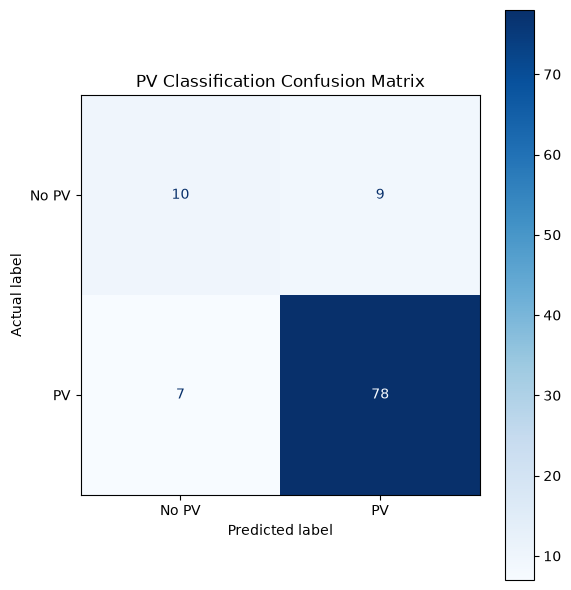

In [28]:
import matplotlib.pyplot as plt

from sklearn.metrics import ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    display_labels=["No PV", "PV"],
    cmap="Blues",
    values_format="d",
    ax=ax
)

ax.set_title("PV Classification Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")

plt.tight_layout()
plt.show()